In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter("ignore")
import omicverse as ov
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.11, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'phate>=1.0' distribution was not found and is required by the application


In [2]:
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [3]:
adata = ov.read('/home/lugli/spuccio/Projects/SP039/GBmap/Cai2024_Part3.h5ad')

In [4]:
adata.obs['scsa_celltype_panglaodb'].value_counts()

scsa_celltype_panglaodb
Macrophages               3798
Neurons                   3036
Bergmann Glia             2210
Microglia                 1744
Fibroblasts               1570
Oligodendrocytes           690
Dendritic Cells            676
Astrocytes                 603
Pericytes                  415
NK Cells                   393
Endothelial Cells          345
Pluripotent Stem Cells     263
Monocytes                  146
Neutrophils                 61
Name: count, dtype: int64

In [5]:
optim_palette=ov.pl.optim_palette(adata,basis='X_umap',colors='scsa_celltype_panglaodb')

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 50.76
|-----> Optimizing color mapping...


In [6]:
adata.var['start_position'] = adata.var['start_position'].astype(int)
adata.var['end_position'] = adata.var['end_position'].astype(int)

In [7]:
adata.var.columns

Index(['mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances',
       'residual_variances', 'ensembl_gene_id', 'start_position',
       'end_position', 'chromosome_name'],
      dtype='object')

In [8]:
adata.var.columns = ['mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances',
       'residual_variances', 'ensembl_gene_id', 'start',
       'end', 'chromosome']

In [9]:
adata.var['chromosome'] = "chr"+adata.var['chromosome'].astype(str)

In [10]:
list(adata.obs['annotation_level_2'].unique())  

['Nan']

In [14]:
adata.obs['scsa_celltype_panglaodb'].value_counts()

scsa_celltype_panglaodb
Macrophages               3798
Neurons                   3036
Bergmann Glia             2210
Microglia                 1744
Fibroblasts               1570
Oligodendrocytes           690
Dendritic Cells            676
Astrocytes                 603
Pericytes                  415
NK Cells                   393
Endothelial Cells          345
Pluripotent Stem Cells     263
Monocytes                  146
Neutrophils                 61
Name: count, dtype: int64

In [13]:
adata

AnnData object with n_obs × n_vars = 15950 × 13647
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'ensembl_gene_id', 'start', 'end', 'chromosome'
    uns: 'donor_id_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'scsa_celltype_cellmarker_colors', 'scsa_celltype_panglaodb_colors', 'umap'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    obsp: 'connectivities', 'distances'

In [17]:
cnv.tl.infercnv(
    adata,
    reference_key="scsa_celltype_panglaodb",
    reference_cat=[
    "Neurons",
    "Bergmann Glia",
    "Microglia","Dendritic Cells","NK Cells","Monocytes","Neutrophils"
    ],
    window_size=250,
)

  0%|          | 0/4 [00:00<?, ?it/s]

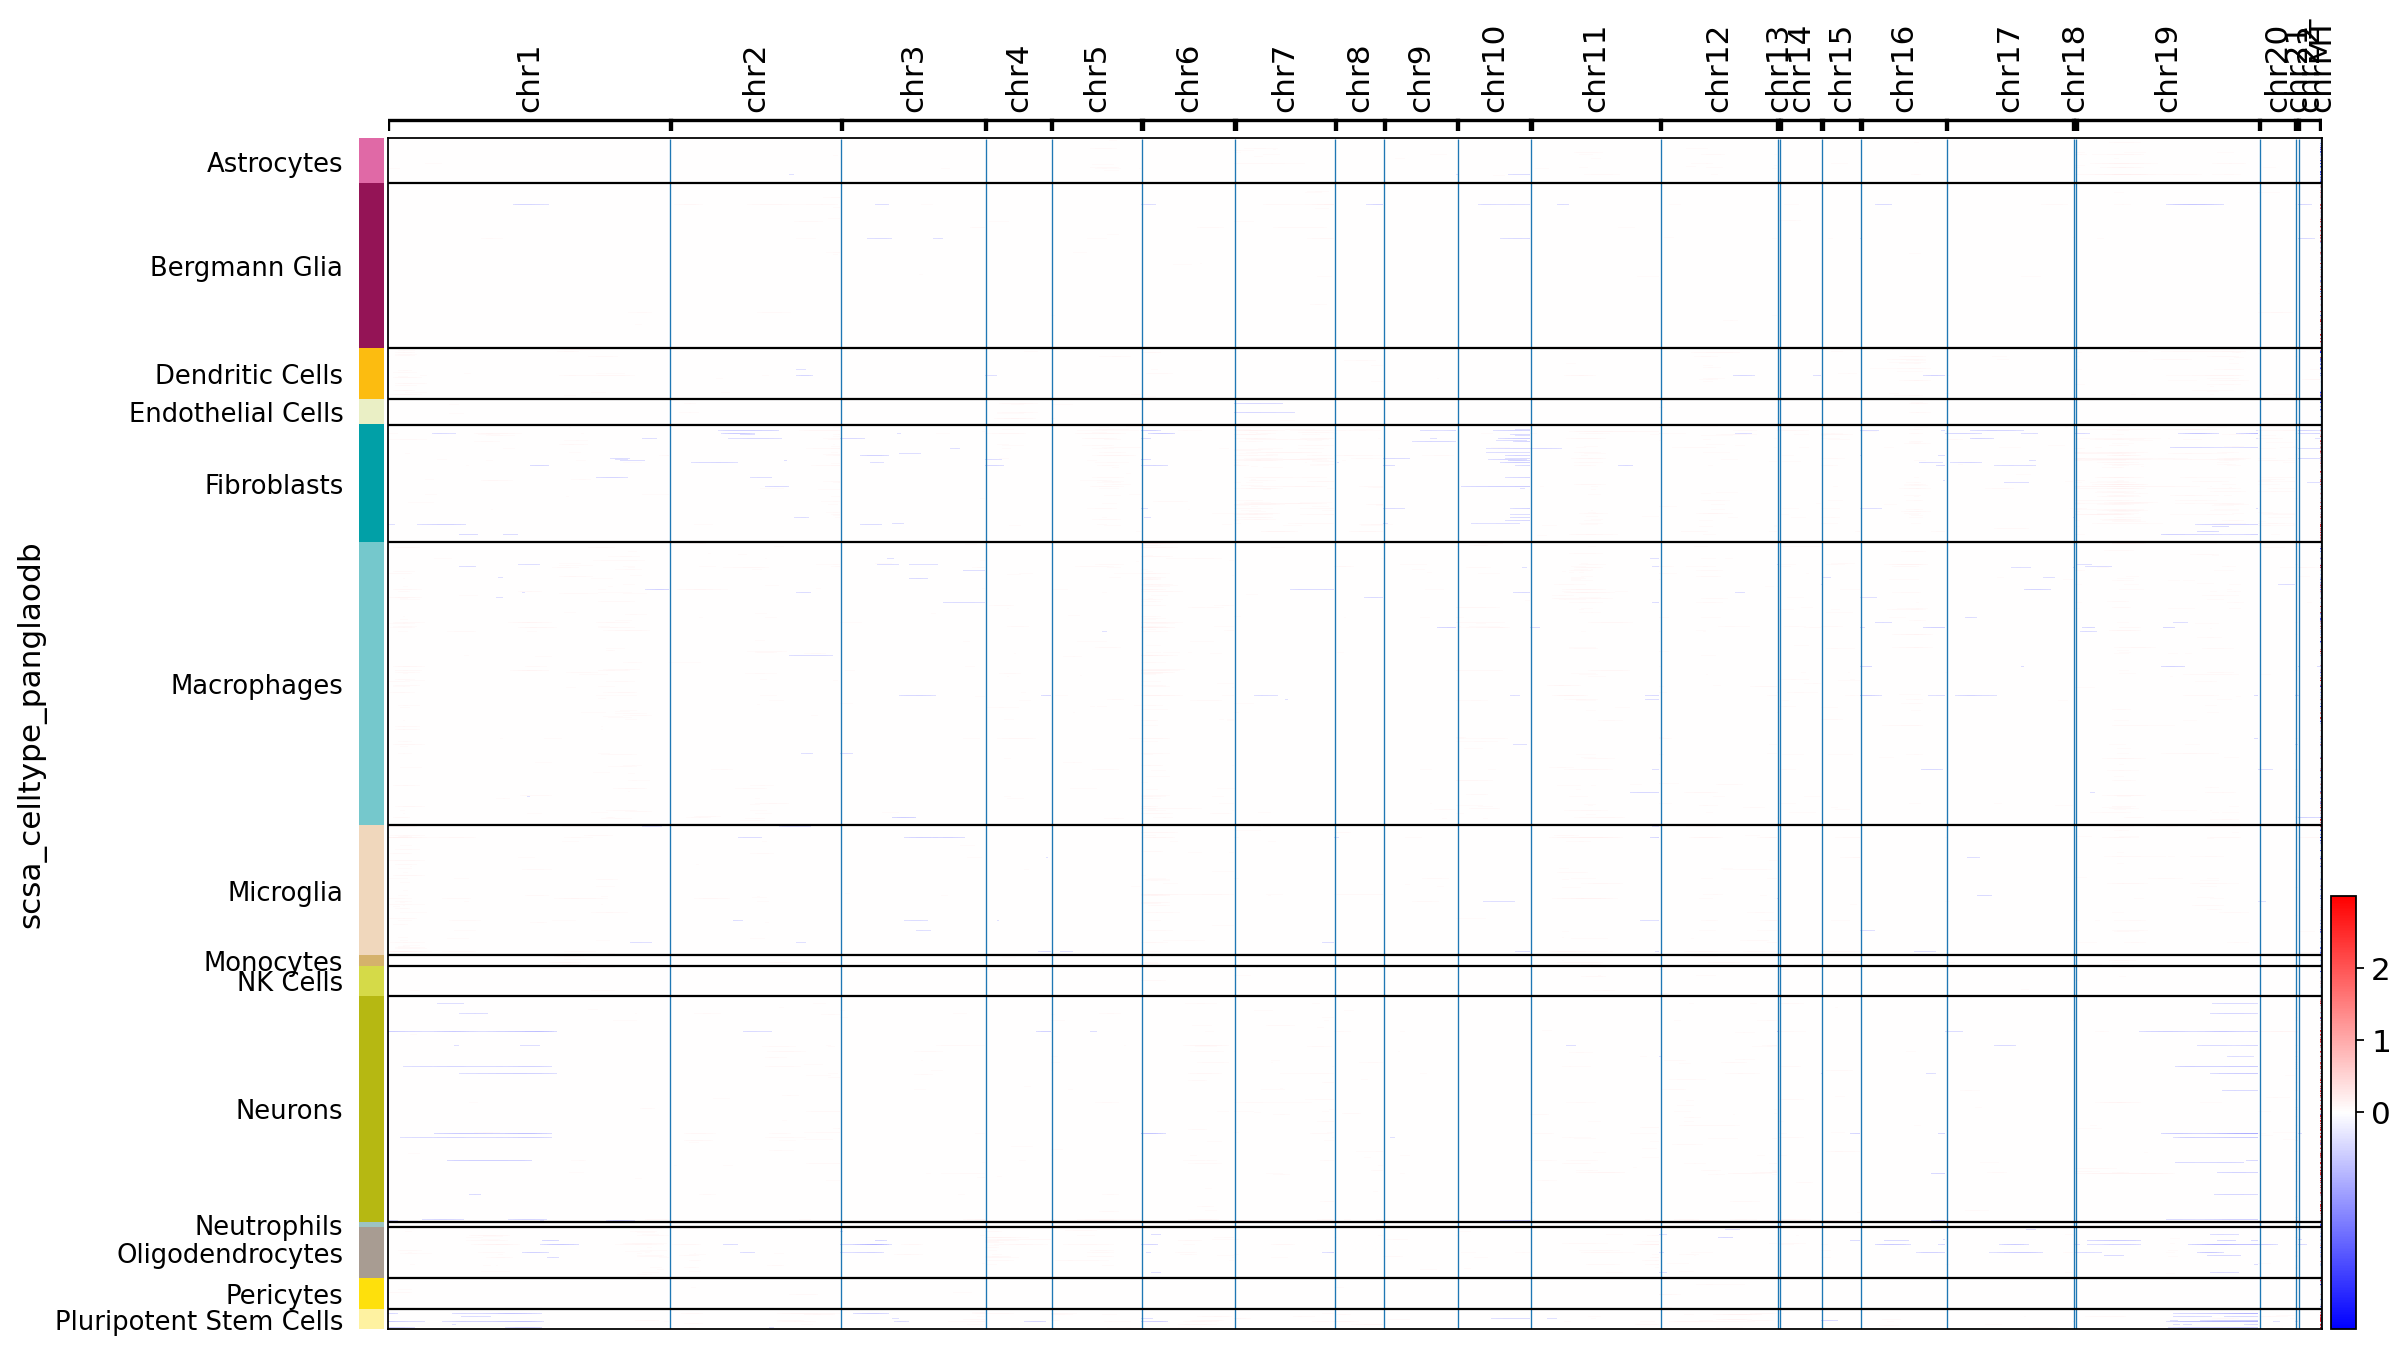

In [18]:
cnv.pl.chromosome_heatmap(adata, groupby="scsa_celltype_panglaodb")

In [19]:
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='X_harmony')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:22)


In [20]:
ov.pp.leiden(adata,resolution=0.4)

running Leiden clustering
    finished: found 23 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:05)


In [21]:
adata.uns['cnv_neighbors'] = adata.uns['neighbors']

In [22]:
cnv.tl.leiden(adata)

running Leiden clustering
    finished: found 37 clusters and added
    'cnv_leiden', the cluster labels (adata.obs, categorical) (0:00:08)


In [23]:
del adata.uns['leiden_colors']

In [24]:
adata

AnnData object with n_obs × n_vars = 15950 × 13647
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'ensembl_gene_id', 'start', 'end', 'chromosome'
    uns: 'donor_id_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'scsa_celltype_cellmarker_colors', 'scsa_celltype_panglaodb_colors', 'umap', 'cnv', 'cnv_neighbors', 'cnv_leiden'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'scaled|original|X_pca', 'X_cnv'
    obsp: 'connectivities', 'distances'

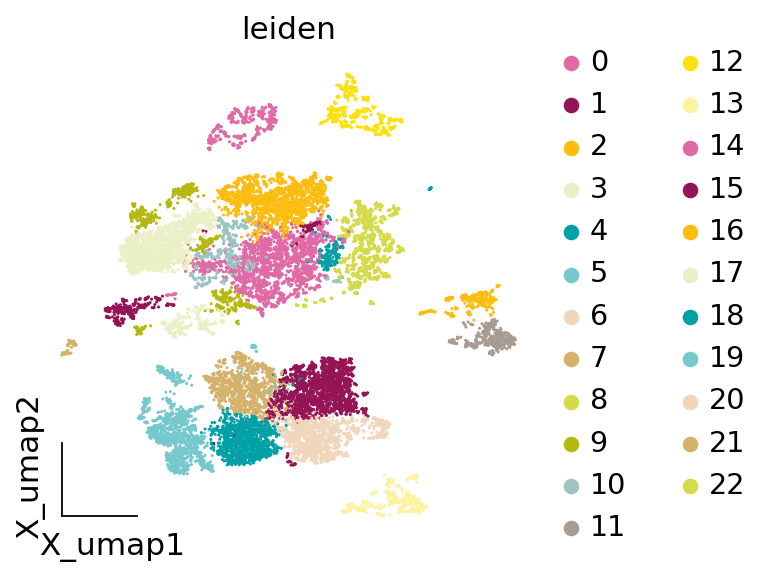

In [25]:
ov.utils.embedding(adata,
                   basis='X_umap',
                   color=['leiden'],
                   frameon='small',
                   legend_fontoutline=2,palette=ov.utils.palette()[14:],wspace=0.5
                  )

In [26]:
optim_palette2=ov.pl.optim_palette(adata,basis='X_umap',colors='leiden')

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 0.00
|-----> Optimizing color mapping...


In [27]:
sc.tl.dendrogram(adata, groupby='leiden')

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


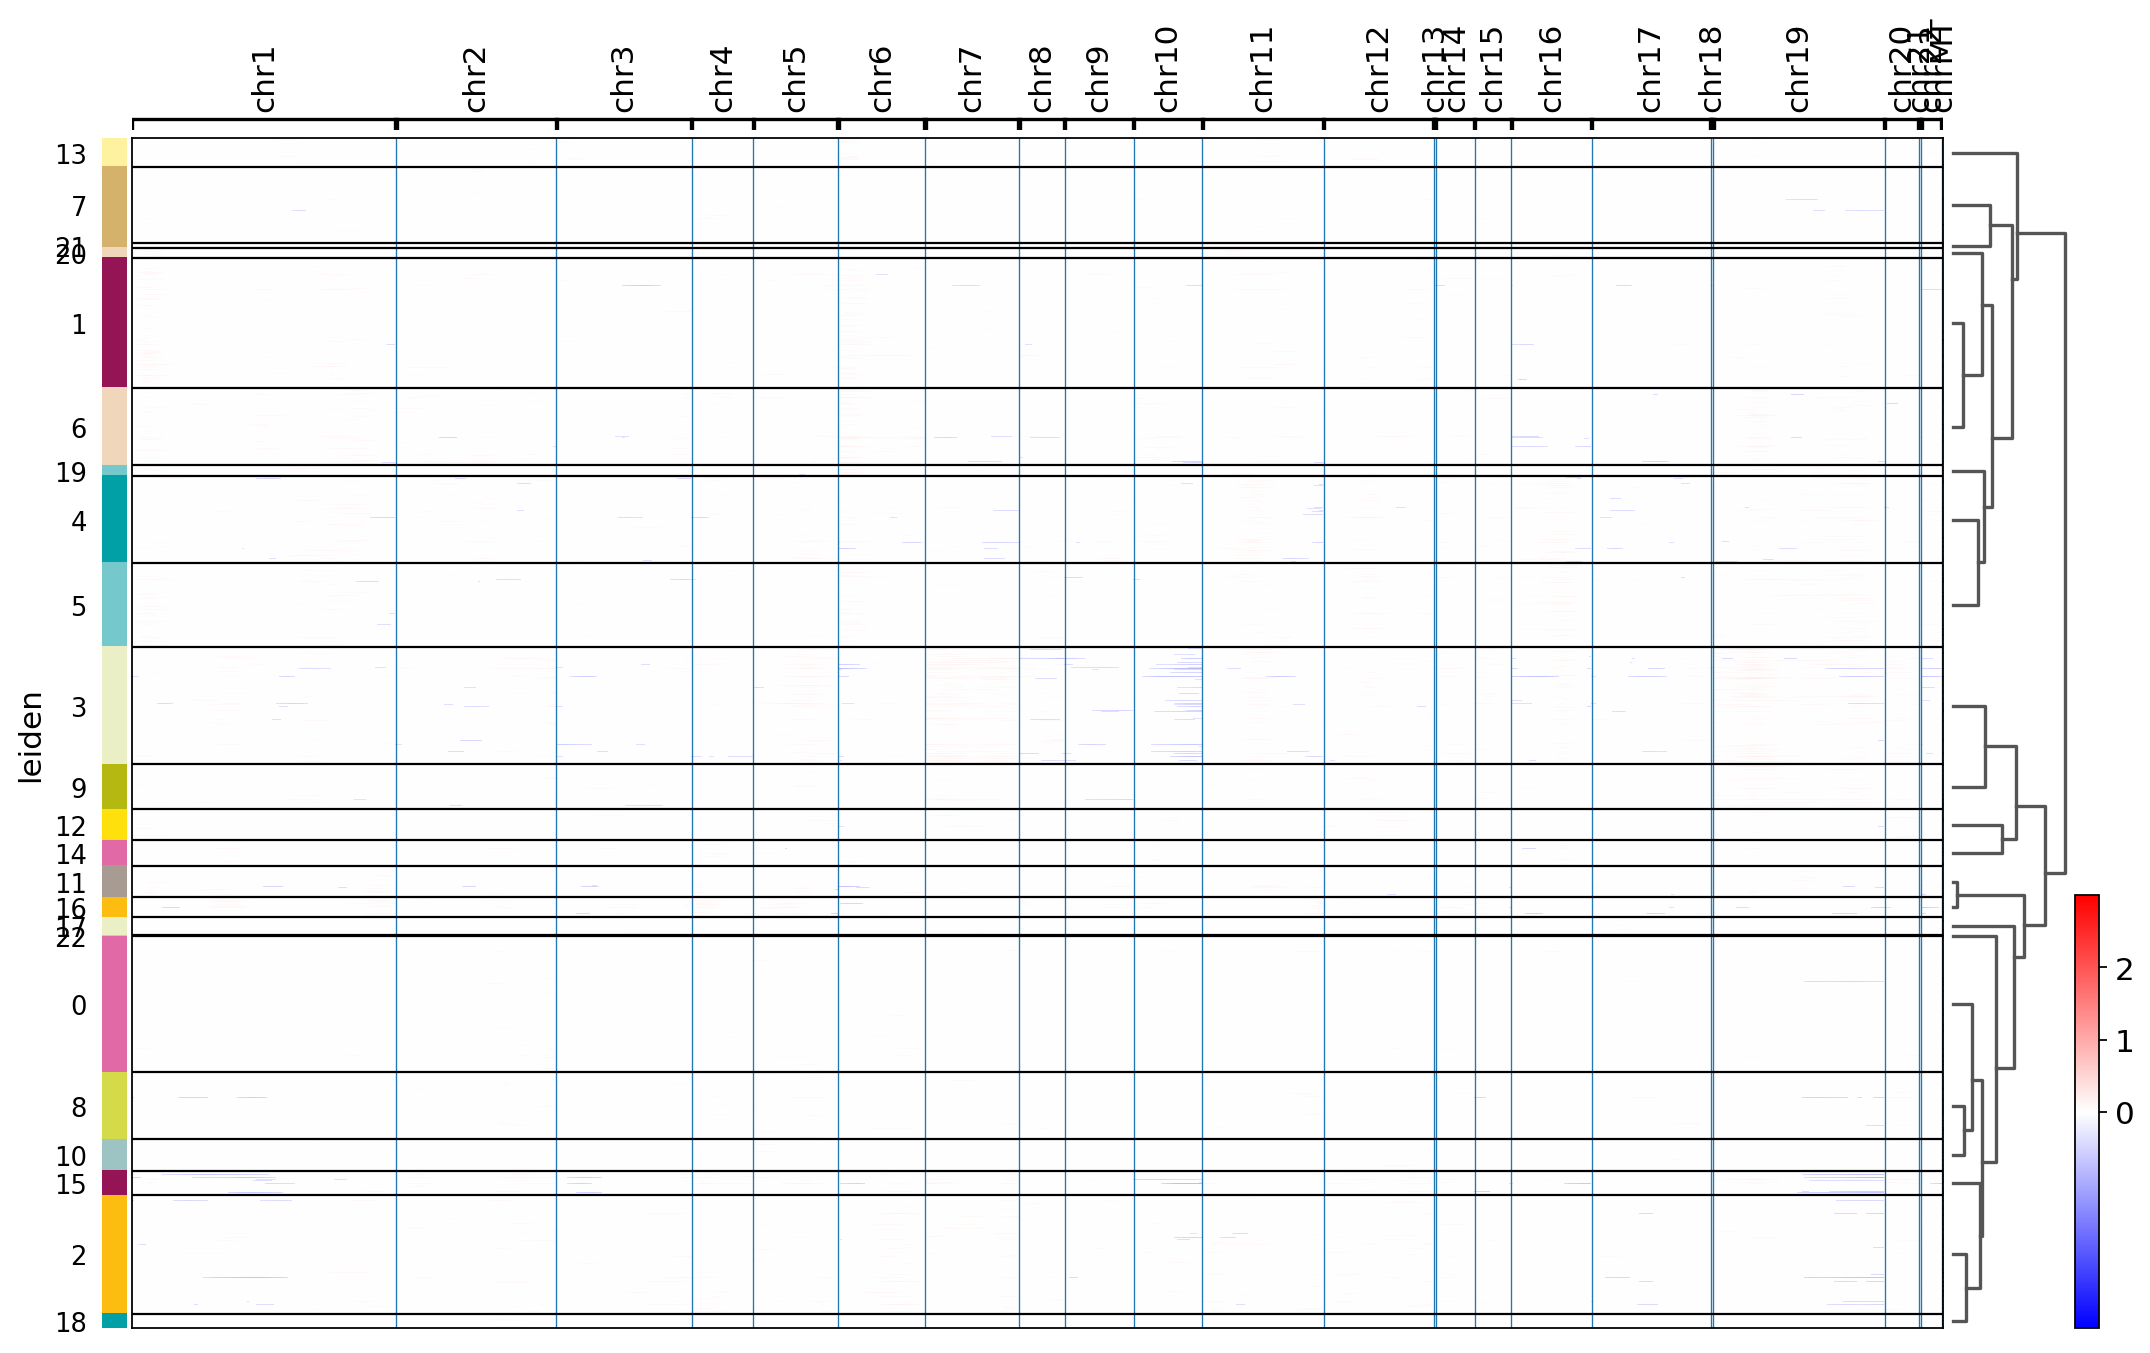

In [28]:
cnv.pl.chromosome_heatmap(adata, groupby="leiden", dendrogram=True)

In [29]:
cnv.tl.cnv_score(adata)

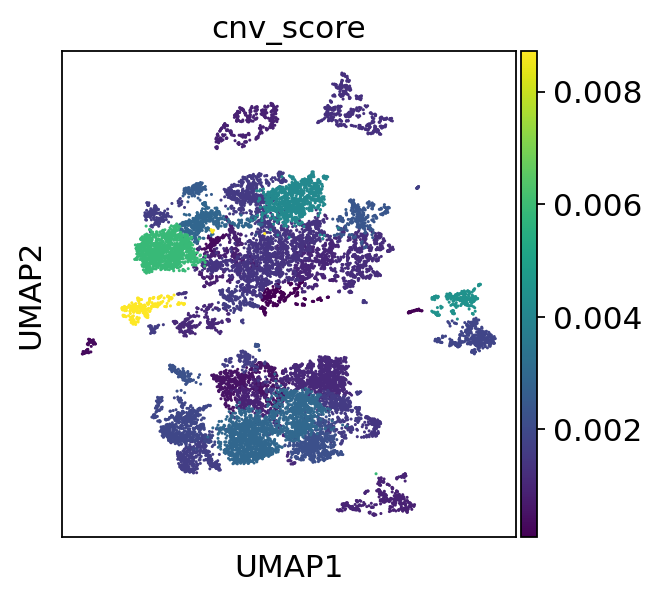

In [30]:
sc.pl.umap(adata, color="cnv_score")

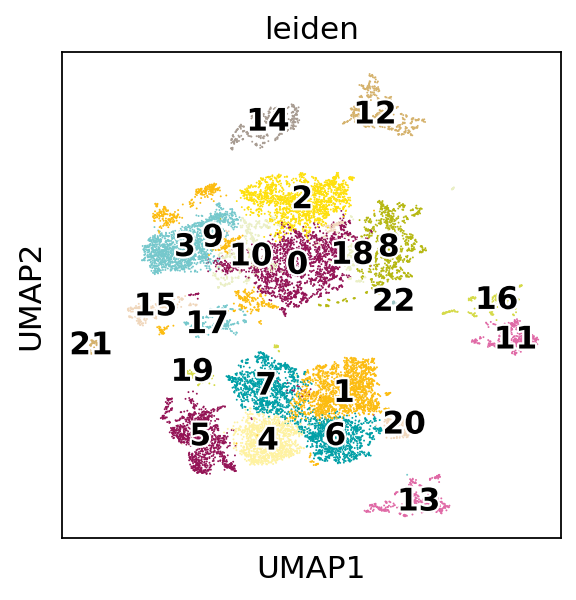

In [31]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",s=3,
    legend_fontoutline=2,palette=optim_palette2
)

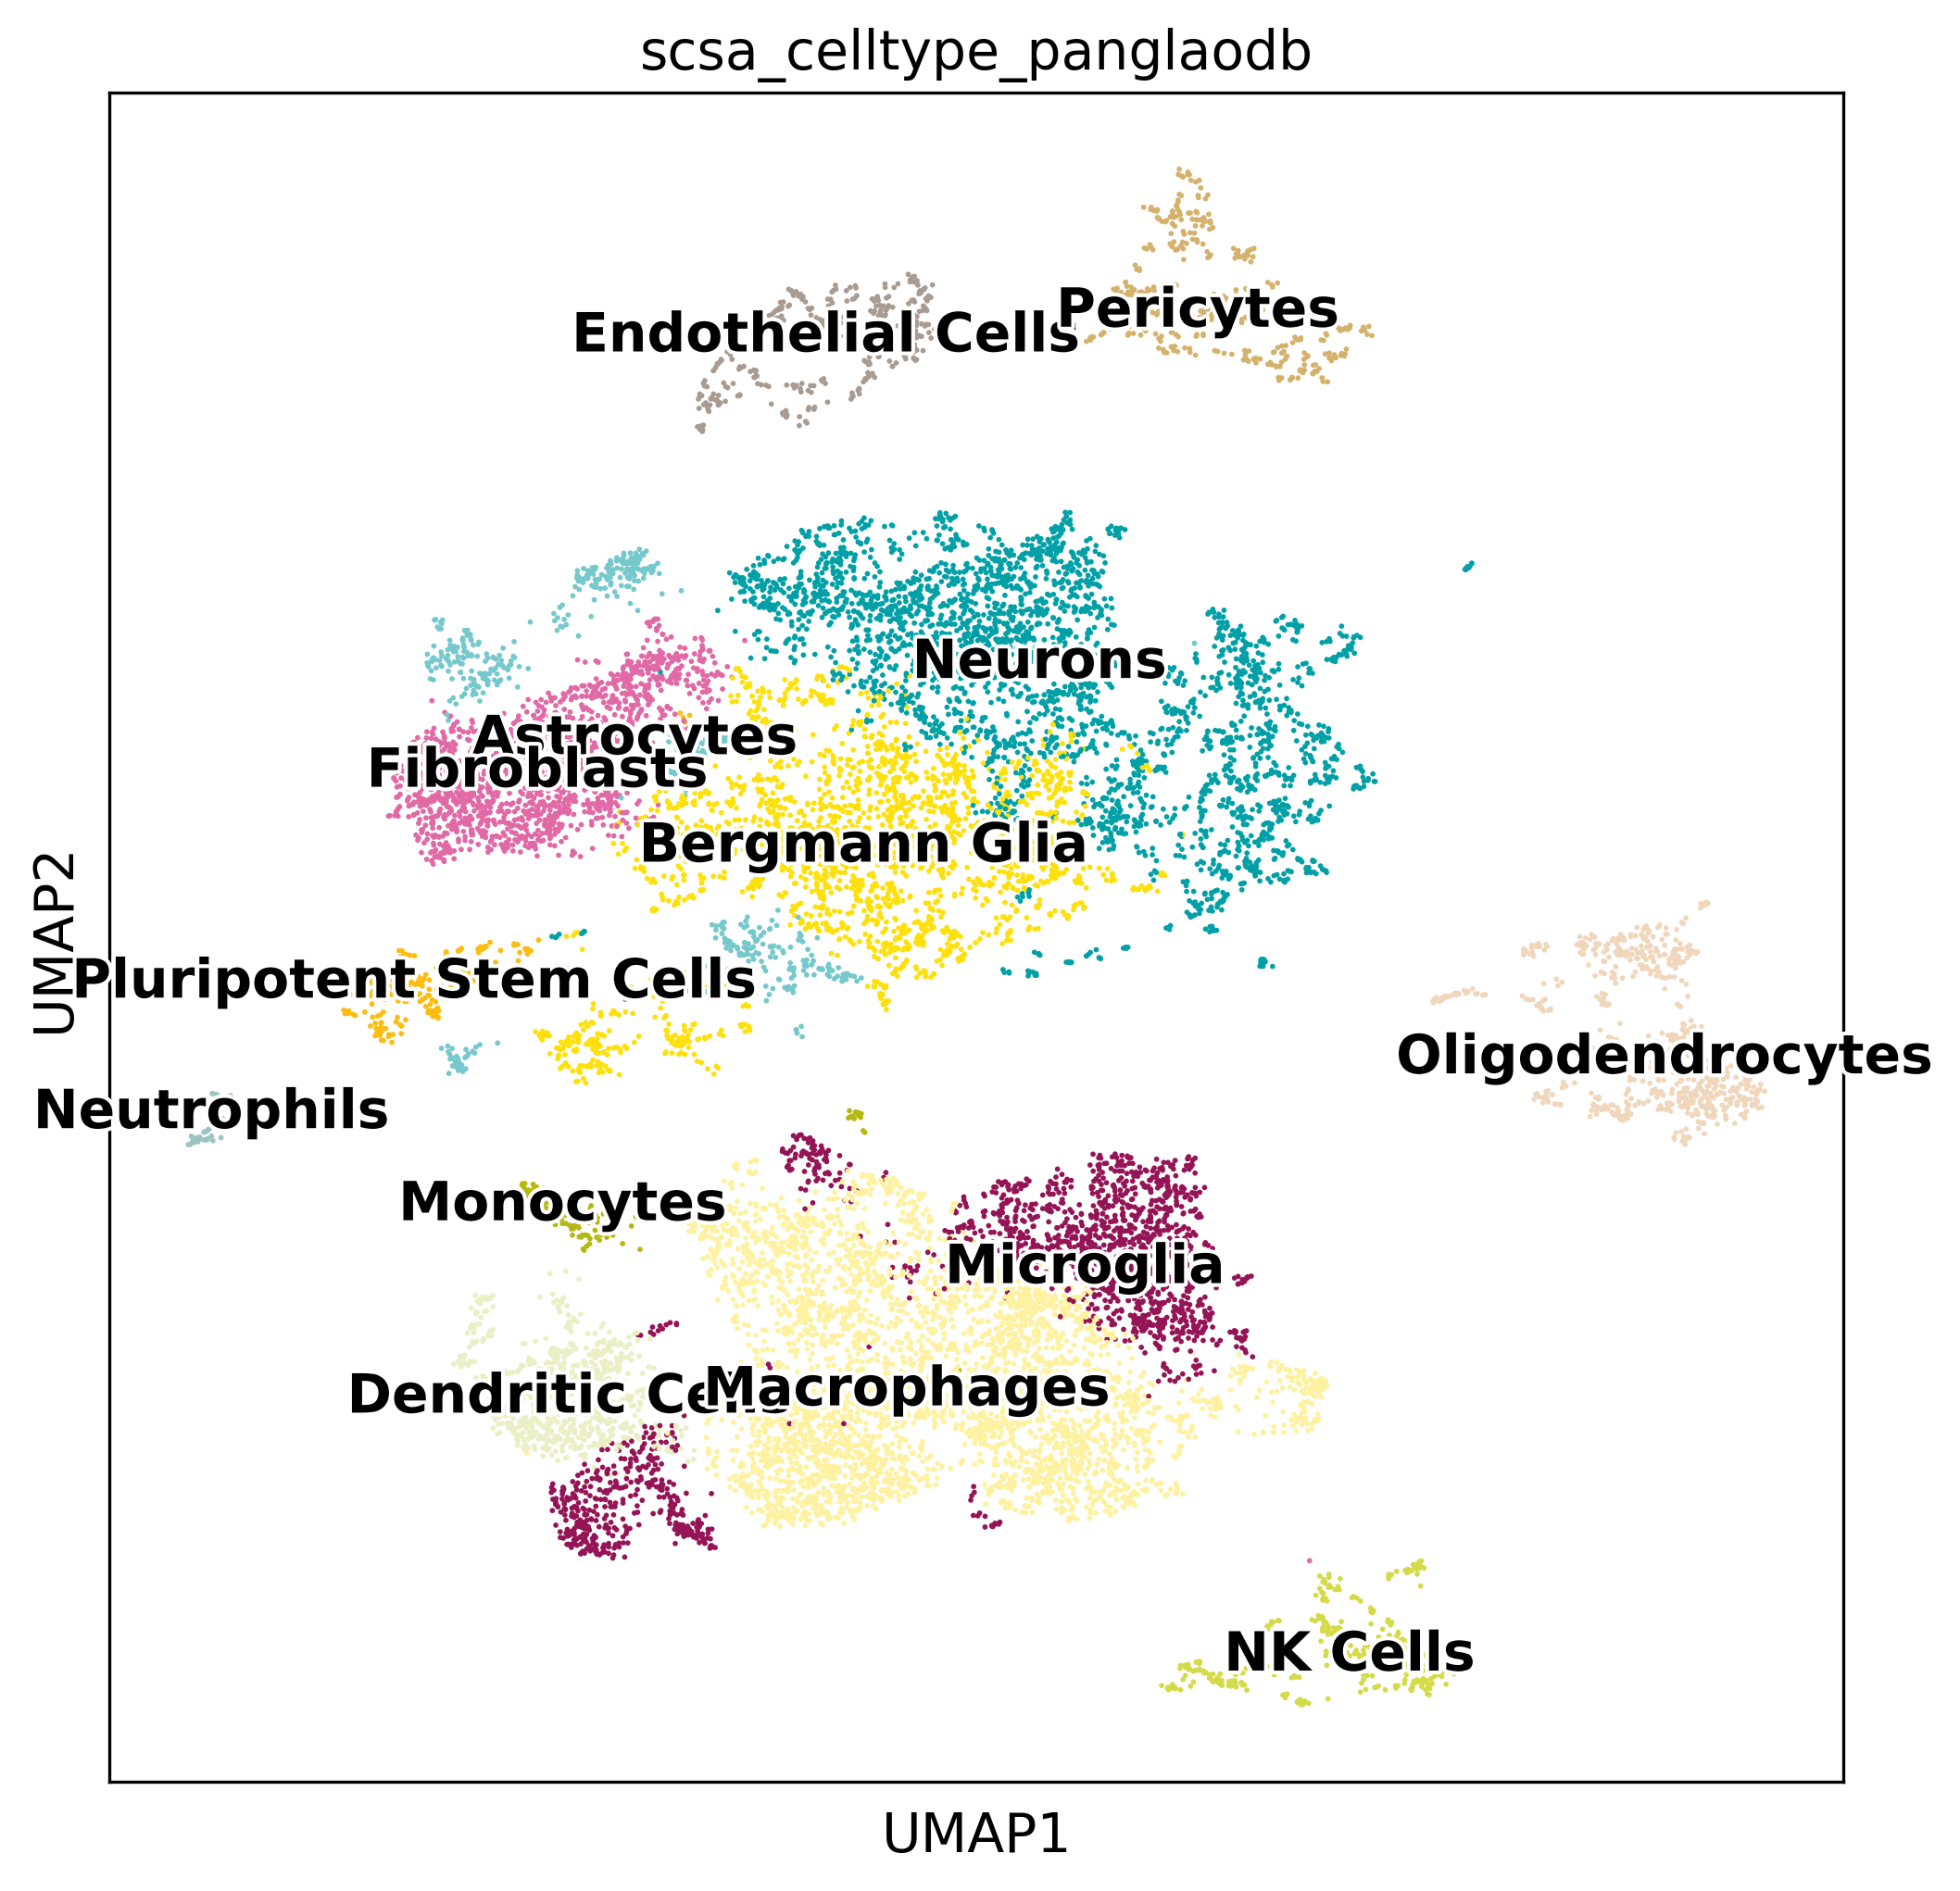

In [32]:
with plt.rc_context({"figure.figsize": (8, 8), "figure.dpi": (150)}):
    sc.pl.umap(
    adata,
    color="scsa_celltype_panglaodb",
    legend_loc="on data",palette=optim_palette,
    legend_fontoutline=2)



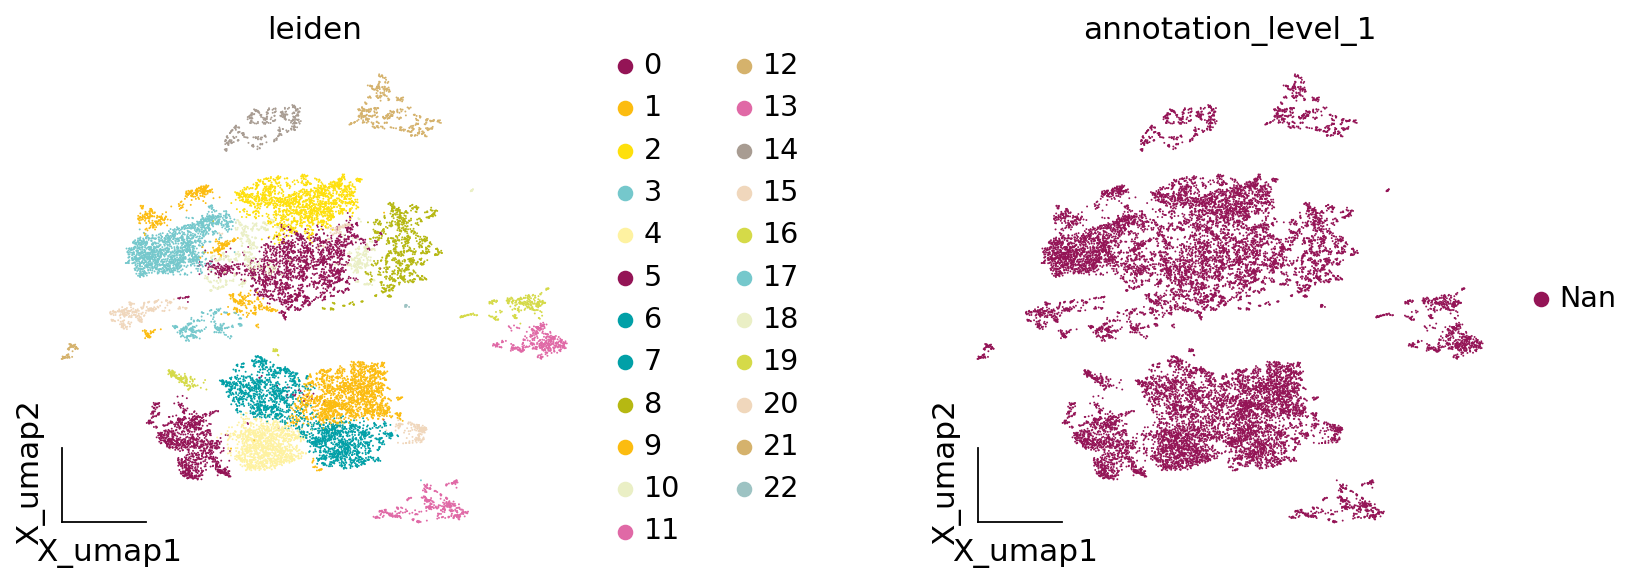

In [33]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden','annotation_level_1'],palette=optim_palette2,s=3,
                frameon='small',wspace=0.5)

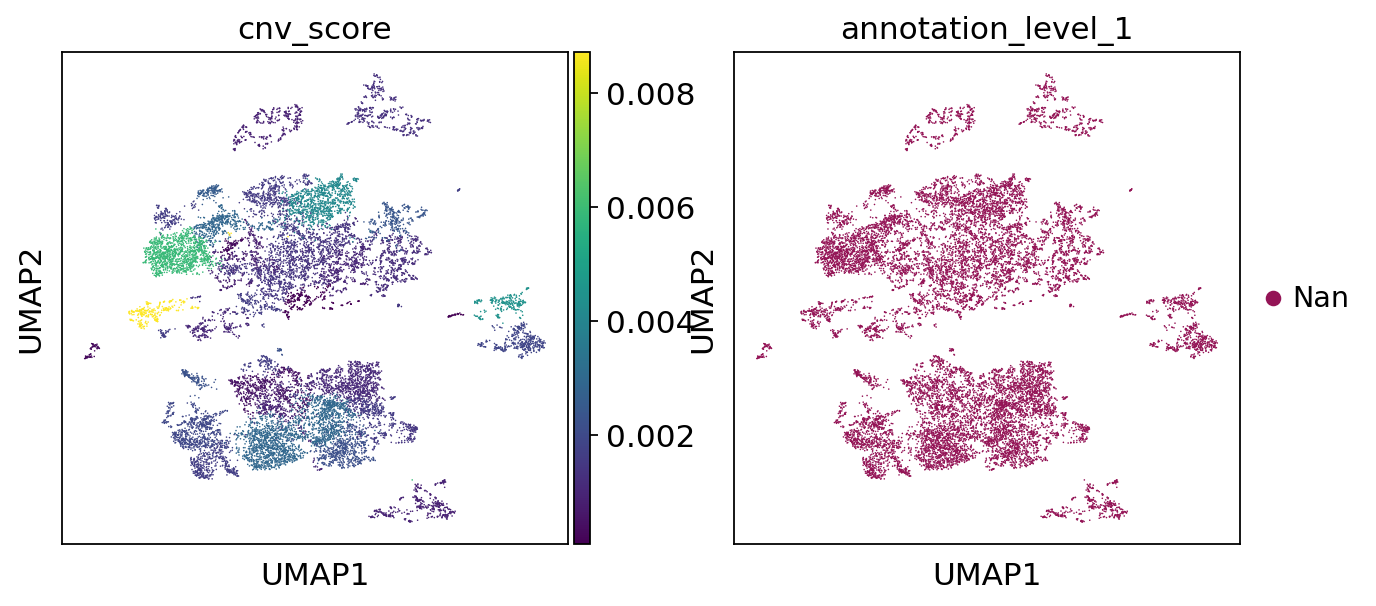

In [34]:
sc.pl.umap(adata, color=["cnv_score","annotation_level_1"],s=2)

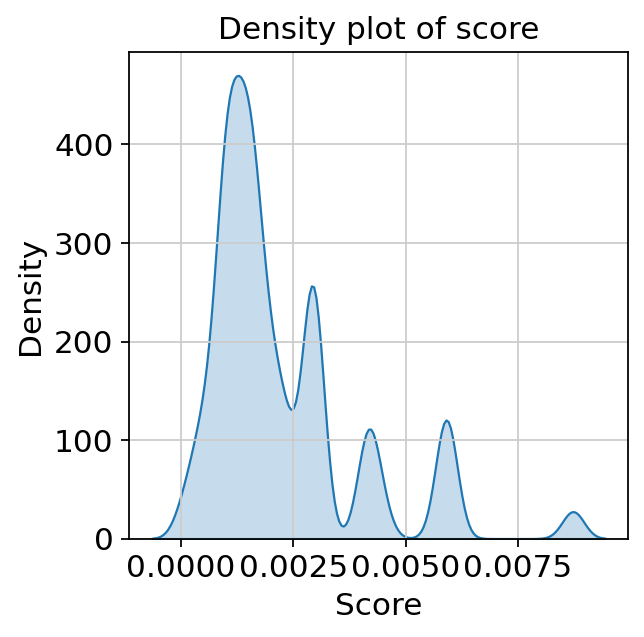

In [35]:
import seaborn as sns
sns.kdeplot(adata.obs["cnv_score"], fill=True)
plt.xlabel("Score")
#plt.axvline(x=filt_var, color='red', linestyle='--', linewidth=2)
plt.title("Density plot of score")
plt.show()

In [40]:
filt_var = 0.0035

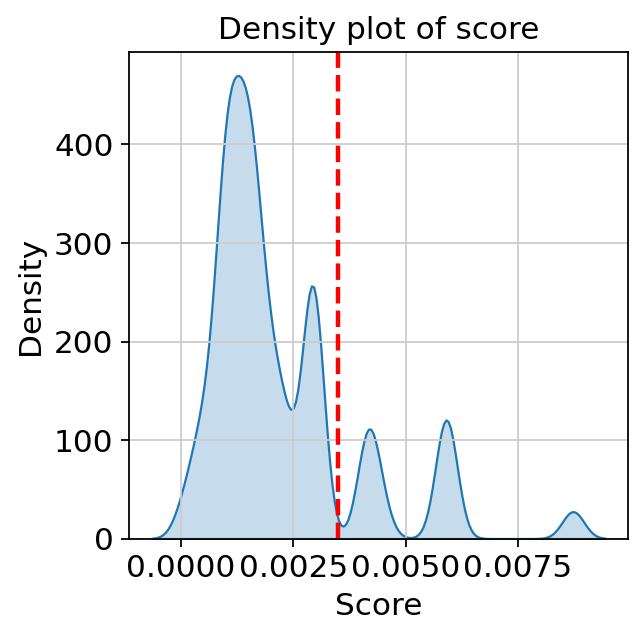

In [41]:
import seaborn as sns
sns.kdeplot(adata.obs["cnv_score"], fill=True)
plt.xlabel("Score")
plt.axvline(x=filt_var, color='red', linestyle='--', linewidth=2)
plt.title("Density plot of score")
plt.show()

In [42]:
immune_cells = [
    "Myeloid",
    "Lymphoid"
]

# Filter out cells that are in immune_cells and have cnv_score > 0.04
filtered_adata = adata[~(
    (adata.obs["annotation_level_2"].isin(immune_cells)) &
    (adata.obs["cnv_score"] > filt_var)
)]

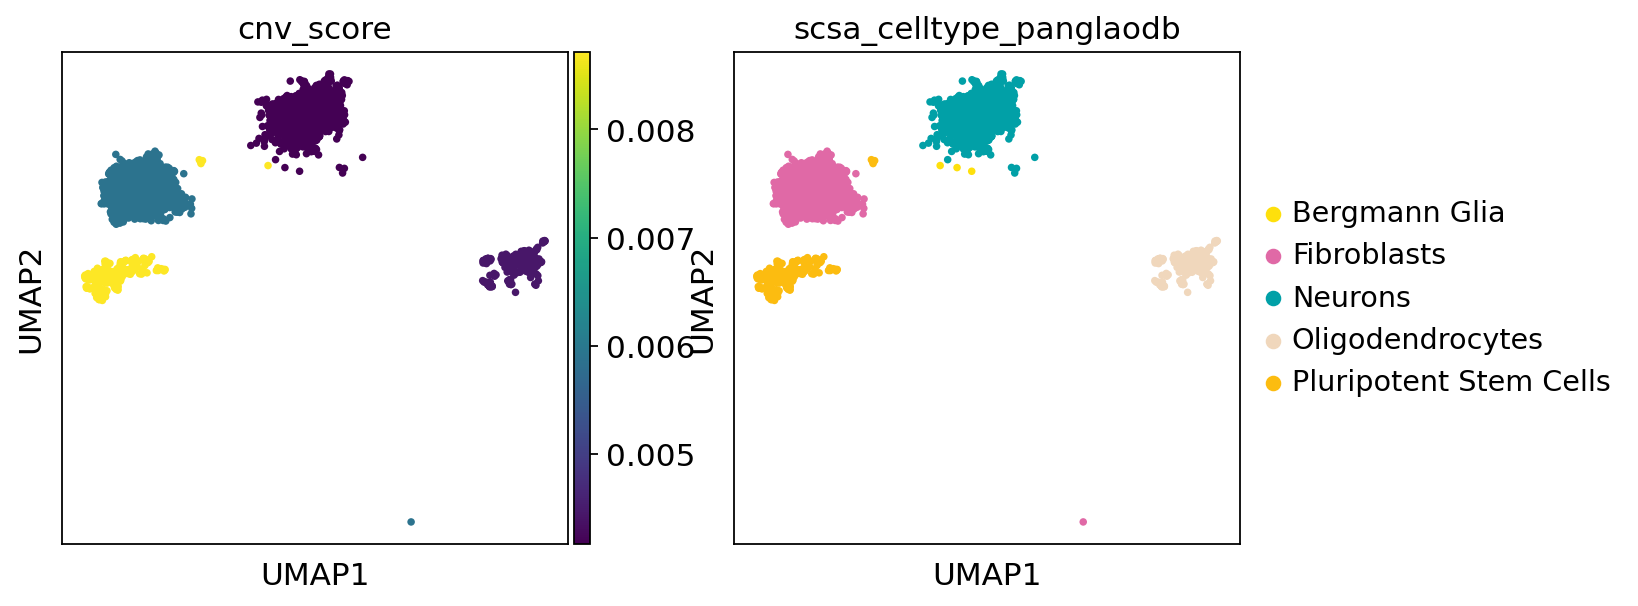

In [44]:
sc.pl.umap(filtered_adata[filtered_adata.obs["cnv_score"] > filt_var,:], color=["cnv_score","scsa_celltype_panglaodb"])

In [45]:
filtered_adata.obs["cnv_status"] = "normal"
filtered_adata.obs.loc[filtered_adata.obs["cnv_score"]> filt_var, "cnv_status"] = (
    "tumor"
)

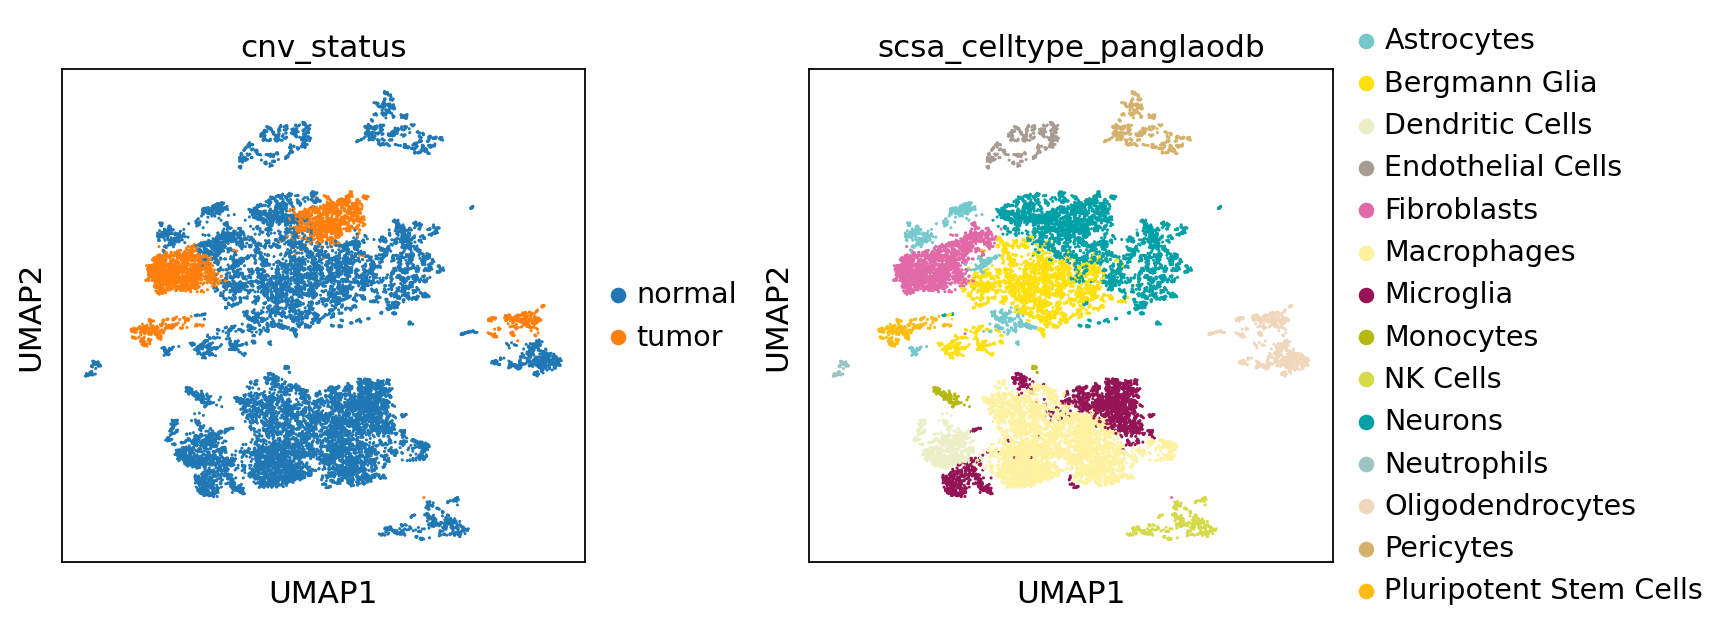

In [47]:
sc.pl.umap(filtered_adata, color=["cnv_status","scsa_celltype_panglaodb"],wspace=0.3)

In [48]:
filtered_adata.obs["annotation_level_1"] = filtered_adata.obs["cnv_status"]

In [49]:
filtered_adata.write("/home/lugli/spuccio/Projects/SP039/GBmap/Cai2024_Part4.h5ad")